# Notebook to Demonstrate NISAR Cal/Val Database GPS Access for Greenland Data
---

This demonstrates and tests the capability of the nisarSation class for working with GPS data processed by JPL for NISAR cryo cal/val activities.

## Python Setup

In [ ]:
%load_ext autoreload
%autoreload 2
import time
#
reset = False
try:
    import nisarcryodb
except Exception:
    %pip install -e ~/./nisarcryodb
    reset = True
try:
    import nisargps
except Exception:
    %pip install -e ~/./nisargps
    reset = True
if reset:
    print('\n\033[1;31m\n\nRestart kernel and run this cell again \n\n \033[0m\n''')
    time.sleep(1e9) # stop from advancing

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import nisargps
import nisarcryodb
import matplotlib.pyplot as plt
from datetime import timedelta, datetime
import pyproj
from scipy.stats import linregress
import calendar
import os
from matplotlib.ticker import MaxNLocator

In [2]:
def decimalYearToDateTime(date):
    if date is np.nan:
        return None
    year = int(date)
    fracYear = date - year
    yearLength = (datetime(year + 1, 1, 1) - datetime(year, 1, 1)).total_seconds() 
    return datetime(year, 1, 1) + timedelta(seconds=fracYear * yearLength)

## Load Data

Station data too big for github, so unzip if compressed after downloading.

Setup station id and path.

In [3]:
configFile = '../nisarcryodb/Notebooks/calvaldb_config.ini'

In [4]:
DB = nisarcryodb.nisarcryodb(configFile=configFile)

User name:  irj
Password:  ········


## Find Stations with Data

In [5]:
if False:  # set True to run this step
    d1 = 2018.0
    d2 = 2030.0
    stations = DB.getColumn('landice', 'gps_station', 'station_name')
    for station in stations:
        if 'test' not in station:
            myData = DB.getStationDateRangeData(station, d1, d2, 'landice', 'gps_data')
            minDate = decimalYearToDateTime(np.min(myData['decimal_year']) )
            maxDate = decimalYearToDateTime(np.max(myData['decimal_year']) )
            
            if minDate is not None:
                print(station, myData['station_id'][0], len(myData['station_id']), end='\t')
                print(minDate.strftime('%Y-%m-%d'), maxDate.strftime('%Y-%m-%d'))


## Setup NIL1

Pass in the already open DB (`DBConnection=DB`) rather than having the station open its own DB connection to allow multiple stations to use the same connection. To speed multiple queries for the same station, `cacheDB=True` (default), will read all the GPS data for the station and save as a Panda data array. For an isolated short query, it may be faster to turn the caching off. If `traceBack=False` (default is `True`), an abbreviated error message will be given rather than the full Python trackeback.

In [6]:
%%time
stationName = 'NIT1'
stationNIT1 = nisargps.nisarStation(stationName, DBConnection=DB, traceBack=False)

2
Caching station data
station_id
CPU times: user 2.61 s, sys: 411 ms, total: 3.02 s
Wall time: 4.65 s


Display the cached data.

In [7]:
stationNIT1.DBData

,gps_data_id,station_id,version_id,date_uploaded,measurement_dt_utc,decimal_year,nominal_doy,lat,lon,ht_abv_eps,sigma_e,sigma_n,sigma_v,tides_x,tides_y,tides_z,data_geom
0,522967,2,5,2025-09-11,2025-01-01 00:00:00,2025.000000,1,-79.793358,-198.656033,-2.707,1.2,1.5,4.7,-6.304,-1.110,0.476,0101000020E6100000761B2F38FED468C0868A5861C6F2...
1,523601,2,5,2025-09-11,2025-01-01 05:17:00,2025.000603,1,-79.793358,-198.656036,-2.594,1.1,1.2,3.9,-1.475,5.049,4.254,0101000020E6100000EB1AB13FFED468C0A620E461C6F2...
2,523602,2,5,2025-09-11,2025-01-01 05:17:30,2025.000604,1,-79.793358,-198.656036,-2.631,1.0,1.1,3.7,-1.458,5.050,4.270,0101000020E6100000CD27863FFED468C0DCC07861C6F2...
3,523603,2,5,2025-09-11,2025-01-01 05:18:00,2025.000605,1,-79.793358,-198.656036,-2.647,1.0,1.1,3.7,-1.442,5.050,4.286,0101000020E6100000235EA63FFED468C04D476361C6F2...
4,523604,2,5,2025-09-11,2025-01-01 05:18:30,2025.000606,1,-79.793358,-198.656036,-2.643,1.0,1.1,3.7,-1.426,5.050,4.302,0101000020E610000076F1653FFED468C032F79861C6F2...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562519,1085486,2,5,2025-09-11,2024-12-31 23:57:30,2024.999995,366,-79.793358,-198.656033,-2.646,1.1,1.3,3.9,-6.271,-1.178,0.510,0101000020E610000039997639FED468C0C7B66F62C6F2...
562520,1085487,2,5,2025-09-11,2024-12-31 23:58:00,2024.999996,366,-79.793358,-198.656034,-2.691,1.1,1.4,4.0,-6.278,-1.165,0.504,0101000020E6100000EFEED83AFED468C0A9C34462C6F2...
562521,1085488,2,5,2025-09-11,2024-12-31 23:58:30,2024.999997,366,-79.793358,-198.656034,-2.650,1.1,1.4,4.2,-6.285,-1.151,0.497,0101000020E61000009615583AFED468C0A9C34462C6F2...
562522,1085489,2,5,2025-09-11,2024-12-31 23:59:00,2024.999998,366,-79.793358,-198.656034,-2.668,1.1,1.4,4.7,-6.291,-1.137,0.490,0101000020E61000001767883AFED468C0359AF961C6F2...


Load a sample data set for a given time intervale. Can be accessed as `stationNIT1.x` (or `.y, .z, .lat, .lon, .date, .epoch`), where `date` provides the date as `datetime` array and `epoch` provides the date as a decimal year.

## Plot Positions

This function plots the relative trajectories of the GPS and computes the velocity two ways 1) `regression`, which uses the slope of the linear fit to the data, and 2) `point`, which uses the difference of the end points divided by time. For this latter method, you can control how many points at the end to average.

In [8]:
def demoPlot(station, date1, date2):
    # Get points
    tides = True # Remove SE tides, leaves normal ocean tides
    date, x, y, z, epoch = stationNIT1.subsetXYZ(date1, date2, sigmaMultiple=3, tides=True)
    # Regression estimagte
    vx, vy, xMean, yMean = stationNIT1.computeVelocity(date1, date2, method='regression', dateFormat="%Y-%m-%d %H:%M:%S", tides=tides)
    # Get date extremes
    minDate = np.nanmin(date).strftime('%Y-%m-%d')
    maxDate = np.nanmax(date).strftime('%Y-%m-%d')
    # Do regression to demo (for plot only, not velocity estimate)
    resultx = linregress(epoch, x)
    resulty = linregress(epoch, y)
    # Compute linear path
    xline = resultx[0] * epoch + resultx[1]
    yline = resulty[0] * epoch + resulty[1]
    # Plot points
    fig, ax = plt.subplots(1, 1, figsize=(20, 10))
    ax.plot(x - x[0], y - y[0], 'r.', markersize=5, label='Regression Points')
    # Compute end point velocities
    for ap, dy, color, markersize in zip([12, 3], [0.045, 0.09], ['black', 'blue'],[3, 3]):
        #continue
        dT = timedelta(days=ap)
        vxPt, vyPt, xMeanPt, yMeanPt = stationNIT1.computeVelocity(date1, date2, method='point', dateFormat="%Y-%m-%d %H:%M:%S", averagingPeriod=24*ap, tides=tides)
        ax.text(0.02, 0.03+dy, f'Point $\\pm${ap}days: vx={vxPt:.1f}, vy={vyPt:.1f}, v={np.sqrt(vxPt**2 + vyPt**2):.1f}',transform=ax.transAxes, fontsize=18)
        label = f'$\\pm${ap}-day end points'
        for myDate in [date1, date2]:
            dateX, x1, y1, z1, epoch1 = stationNIT1.subsetXYZ(myDate-dT, myDate+dT, sigmaMultiple=3, tides=True)
            ax.plot(x1 - x[0], y1 - y[0], '.', color=color, markersize=markersize, label=label)
            label = None
    # Plot regression
    ax.plot(xline-x[0], yline-y[0], 'orange', linewidth=2, label='Regression')
    # Decorate plot
    ax.set_xlabel('X (m)', fontsize=16)
    ax.set_ylabel('Y (m)', fontsize=16)
    ax.text(0.02, 0.03, f'Regression: vx={vx:.1f}, vy={vy:.1f}, v={np.sqrt(vx**2 + vy**2):.1f}',transform=ax.transAxes, fontsize=18)
    ax.legend()
    ax.set_title(f'Station {stationNIT1.stationName} Trajectory from {minDate} to {maxDate}', fontsize=14) 
    for lab  in ax.get_xticklabels() + ax.get_yticklabels():
        lab.set_fontsize(14)

Plot June data when there are continuous data.

EPSG 3031


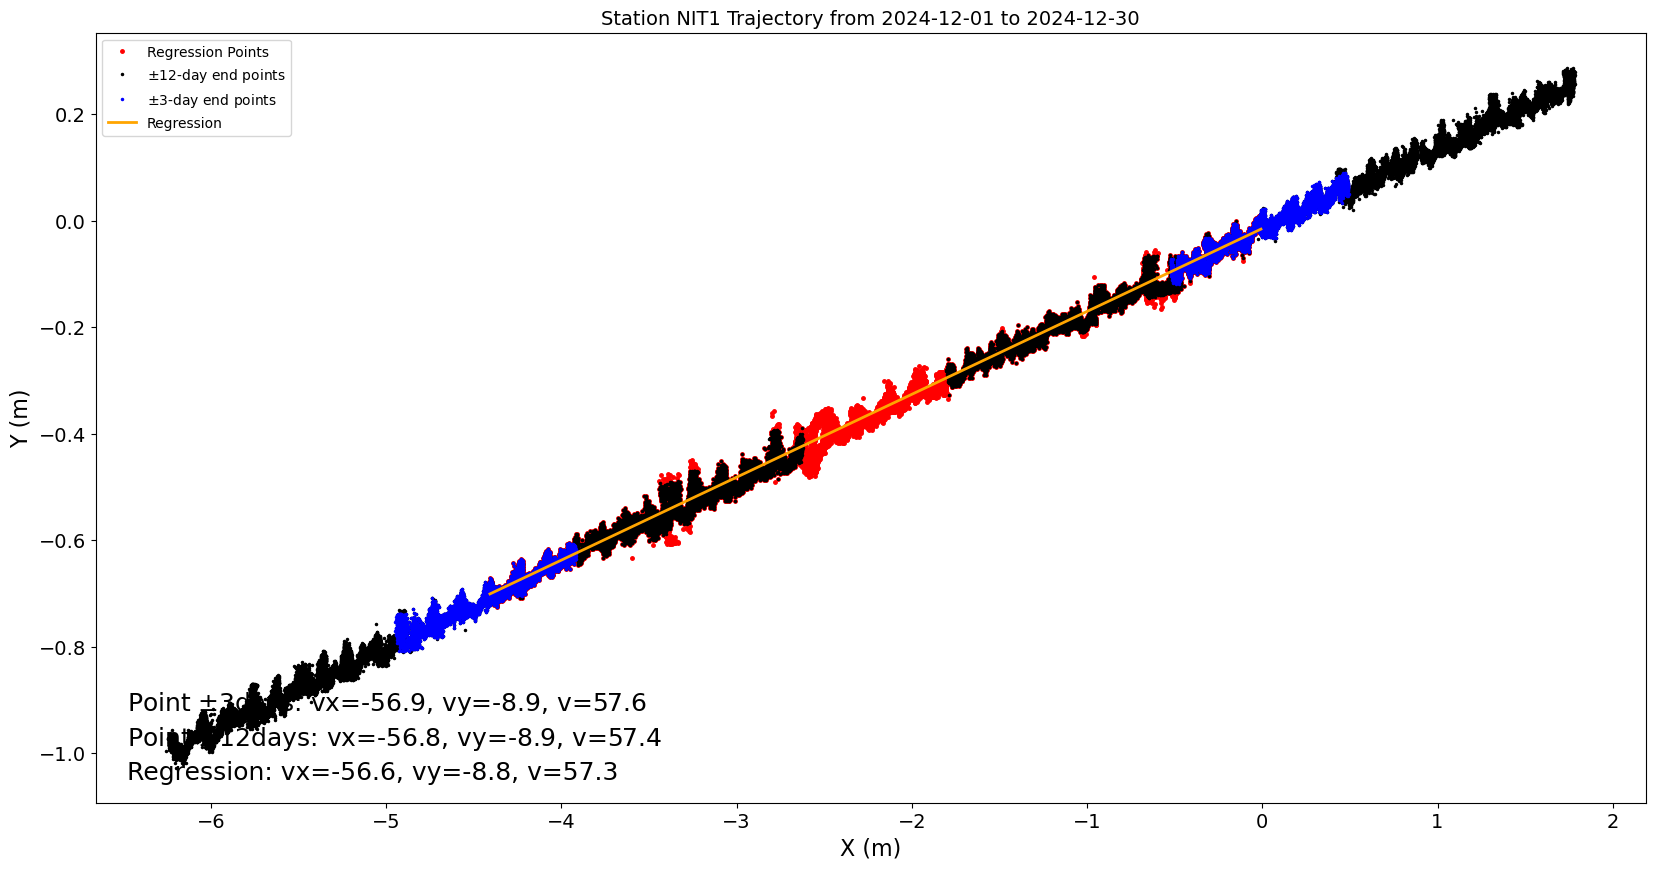

In [9]:
date1 = datetime(2024, 12, 1)
date2 = datetime(2024, 12, 30)
demoPlot(stationNIT1, date1, date2)

Winter case with daily data.

Text(0, 0.5, 'Vertical Displacement (m)')

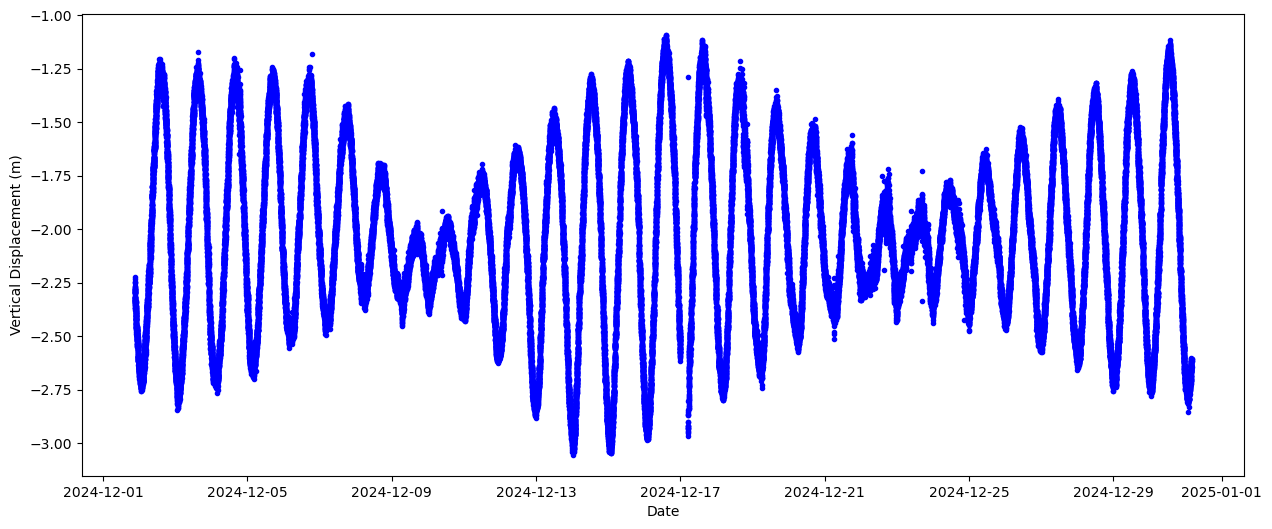

In [10]:
date1 = datetime(2024, 12, 1)
date2 = datetime(2024, 12, 30)
date, x, y, z, epoch= stationNIT1.subsetXYZ('2024-12-01 21:01:01', '2024-12-31 03:59:59', dateFormat='%Y-%m-%d %H:%M:%S', minPoints=1, traceBack=True)
fig, ax = plt.subplots(1, 1, figsize=(15, 6),)
ax.plot(date, z, 'b.')
ax.set_xlabel('Date')
ax.set_ylabel('Vertical Displacement (m)')

## Compute and Plot Time Series

This section demonstrates the estimate of a velocity time series over a given period. There are two methods:
- `point`, which computes the position averaged over some interval (`averagingPeriod`)
- `regression` this method computes the velocity of slope for all the points over the period of interest.

The method is specified with the `method` keyword. Either method generates the series from `date1` to `date2`, sampled at increments of `sampleInterval` hours. Velocities are computed with a `dT` specfied in hours. Further research is needed to best determine the velocity for NISAR cal/val. In this example, the standard deviations of the velocities computed using the two methods are 0.6 and 1.7 m/yr, respectively. The differences arise because of the large diurnal variation in speed on the floating ice. The results should be much better on grounded ice. 

### End-Point Estimation vs. Regression

The `regression` estimates at short intervals are more susceptible to short-period (~ 1 day) errors in the GPS than those derived with the `point` method. With increasing length of time, $\Delta t$, used to derive the estimates, the `regression` estimate tend to be better. Since the error at each endpoint is generally the same, $\sigma_v \sim \frac{\sigma_{pt}}{\Delta t}$, the`point` estimate error declines linearly with $\Delta t$ (or equivalently the number of points, $N$). With the regression the error declines with both $\sqrt{N}$ and $\Delta t$, so that  $\sigma_v \sim \frac{\sigma_{pt}}{\sqrt{N} \Delta t} \sim \frac{\sigma_{pt}}{{\Delta t}^{1.5}}$. As a result, its best to use the `point` method for short-interval estimates (a few days or less) and the `regression` method for longer-interval estimates.

This dependence of the error on the estimation period is illustrated below.

1 2 3 4 6 12 18 24 

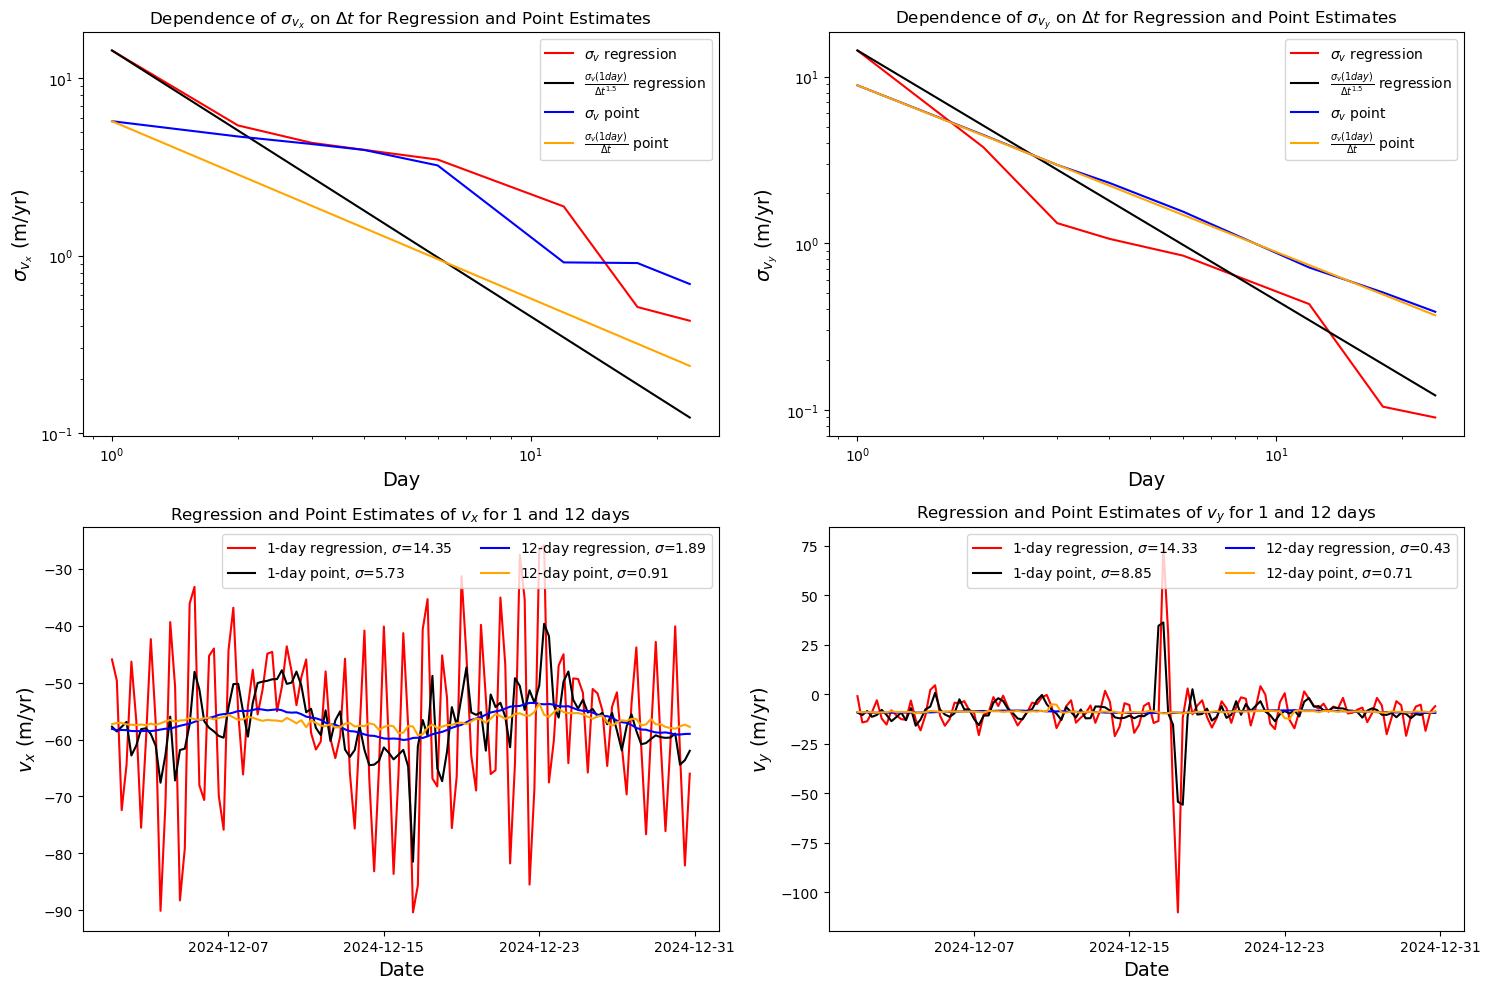

In [12]:
date1 = datetime(2024, 12, 1)
date2 = datetime(2024, 12, 31)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
tides = True # Remove SE tides, leaves normal ocean tides
dt, sigxR, sigyR, sigxP, sigyP  = [], [], [], [], []
vxRall, vxPall, vyRall, vyPall, dates = {}, {}, {}, {}, {}
sampleInterval = 6 # Estimate every 12 hours
averagingPeriod = 4 # Number of hours used to estimate the end points
for d in [1, 2, 3, 4, 6, 12, 18, 24]:
    dT = 24 * d # Compute speed multiple of 1 day interval
    print(d, end=' ')
    #
    # Regression Estimates
    dateR, vxR, vyR, _, _ = stationNIT1.computeVelocityTimeSeries(date1 - timedelta(days=d/2), date2+ timedelta(days=d/2),
                                                                  dT, sampleInterval,
                                                                  method='regression', tides=tides)
    sigxR.append(np.nanstd(vxR))
    sigyR.append(np.nanstd(vyR))
    vxRall[d] = vxR
    vyRall[d] = vyR
    #
    # Point Estimates
    dateP, vxP, vyP, _, _ = stationNIT1.computeVelocityTimeSeries(date1 - timedelta(days=d/2), date2 + timedelta(days=d/2),
                                                                  dT, sampleInterval, averagingPeriod=averagingPeriod, 
                                                                  method='point', tides=tides)
    sigxP.append(np.nanstd(vxP))
    sigyP.append(np.nanstd(vyP))
    vxPall[d] = vxP
    vyPall[d] = vyP
    dates[d] = dateP
    # Save time
    dt.append(dT)
# convert to days
dt = np.array(dt)/24
# 
# Plot sigma dependence
for component, sigR, sigP, ax in zip(['x', 'y'], [sigxR, sigyR], [sigxP, sigyP], axes[0, :]):
    ax.plot(dt, sigR, 'r', label=r'$\sigma_v$ regression')
    ax.plot(dt, sigR[0]/(np.array(dt))**1.5, 'k', label=r'$\frac{\sigma_v(1 day)}{\Delta t^{1.5}}$ regression')
    ax.plot(dt, sigP, 'b', label=r'$\sigma_v$ point')
    ax.plot(dt, sigP[0]/(np.array(dt)), 'orange', label=r'$\frac{\sigma_v(1 day)}{\Delta t}$ point')
    ax.set_title(f'Dependence of $\\sigma_{{v_{{{component}}}}}$ on $\\Delta t$ for Regression and Point Estimates')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylabel(f'$\\sigma_{{v_{{{component}}}}}$ (m/yr)', fontsize=14)
    ax.set_xlabel('Day', fontsize=14)
    ax.legend()
#
# Plot 1 and 12 days
for component, vR, vP, ax in zip(['x', 'y'], [vxRall, vyRall ], [vxPall, vyPall], axes[1, :]):
    ax.plot(dates[1], vR[1], 'r', label=f'1-day regression, $\\sigma$={np.std(vR[1]):.2f}')
    ax.plot(dates[1], vP[1], 'k', label=f'1-day point, $\\sigma$={np.std(vP[1]):.2f}')
    ax.plot(dates[12], vR[12], 'b', label=f'12-day regression, $\\sigma$={np.std(vR[12]):.2f}')
    ax.plot(dates[12], vP[12], 'orange', label=f'12-day point, $\\sigma$={np.std(vP[12]):.2f}')
    ax.set_title(f'Regression and Point Estimates of $v_{component}$ for 1 and 12 days')
    ax.legend(ncol=2)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.set_xlabel('Date', fontsize=14)
    ax.set_ylabel(f'$v_{component}$ (m/yr)', fontsize=14)
    fig.tight_layout()
    #ax.plot(dt, sigxP, 'b', label=r'$\sigma_v$')
  #  ax.plot(dt, sigxP[0]/(np.array(dt)), 'orange', label=r'$\frac{\sigma_v}{\Delta t}$')

In this example, its clear that the 1-day `point` estimates are superior, but at 12 days `regression` provides the best esimates. Note there is some tide-related variation in speed here, see Brunt et. al., Journal of Glaciology, Vol. 56, No. 195, 2010. 